# Beam on an Elastic (Winkler) Foundation

A **member** can rest on a **Winkler foundation** — a continuous bed of springs of stiffness $k_f$ (the modulus of subgrade reaction, per unit length of beam) that pushes back in proportion to the local deflection, $q(x) = -k_f\,v(x)$. This models strip and raft footings, railway track, and pipelines.

```{note}
**"Member" and "span" mean the same thing.** PyCBA builds a beam from *members*, added with `add_member` (or equivalently `add_span` — the two are aliases for the element between two nodes). A member carrying a foundation is automatically *meshed* into many short Euler–Bernoulli **sub-elements** and condensed back to its two end nodes — a "super-element", the same internal-meshing pattern the [nonlinear analysis](nonlinear.ipynb) uses. The meshing is invisible: the member still has just two nodes, so reactions, plotting and influence lines are unchanged.
```

Pass `kf=` to `BeamAnalysis` (a scalar for every member, or one value per member). The mesh density defaults to the foundation characteristic length

$$ \lambda = \left(\frac{4EI}{k_f}\right)^{1/4}. $$

This first version supports prismatic, fixed-fixed members (no `GAv`) carrying UDL, point and partial-UDL loads.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pycba as cba

## Validation against Hetényi

For a long member ($L \gg \lambda$) under a central point load $P$, Hetényi's infinite-beam solution gives the deflection and moment under the load as

$$ v_0 = \frac{P\beta}{2k_f}, \qquad M_0 = \frac{P}{4\beta}, \qquad \beta = \frac{1}{\lambda} = \left(\frac{k_f}{4EI}\right)^{1/4}. $$

We model a free–free member (the foundation alone supports it) and compare. The schematic at the top of the results shows the member resting on its foundation (the row of springs) with the applied load.

under the load:  v0 = -0.1250  (Hetenyi -0.1250)
                 M0 = 0.2494   (Hetenyi 0.2500)


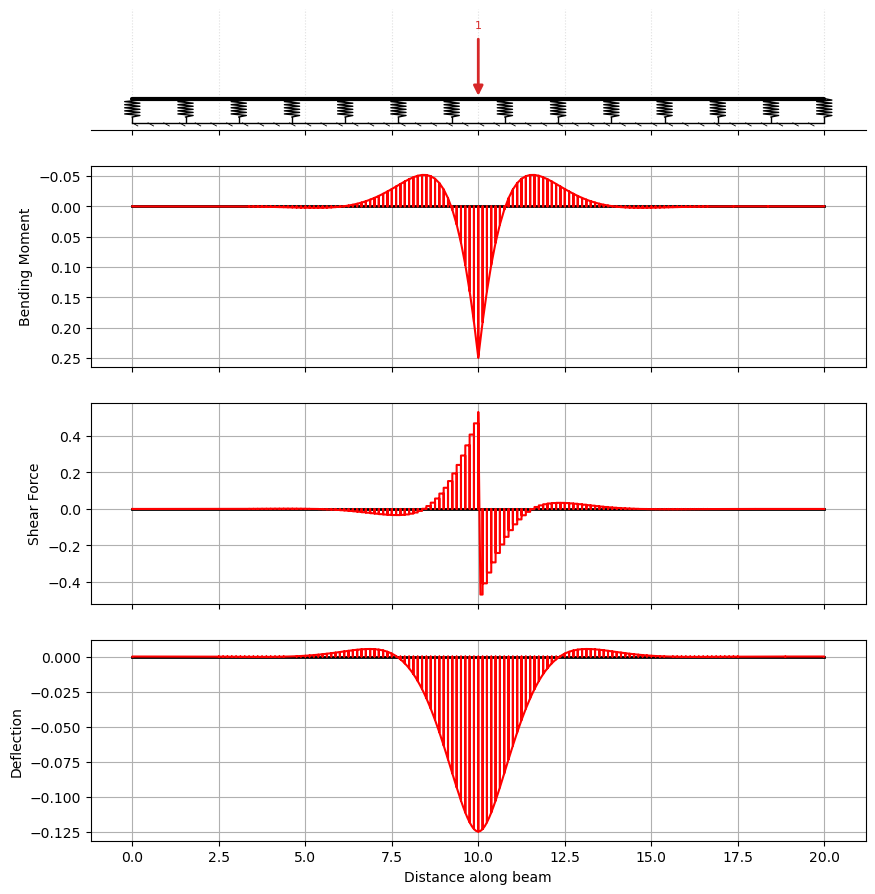

In [2]:
L, EI, kf, P = 20.0, 1.0, 4.0, 1.0      # lambda = 1 -> L/lambda = 20 (long)
beta = (kf / (4 * EI)) ** 0.25

ba = cba.BeamAnalysis([L], EI, [0, 0, 0, 0], kf=kf)   # free-free member on a foundation
ba.add_pl(i_span=1, p=P, a=L / 2)
ba.analyze()
res = ba.beam_results.results

i = np.argmin(np.abs(res.x - L / 2))
print(f"under the load:  v0 = {res.D[i]:+.4f}  (Hetenyi {-P*beta/(2*kf):+.4f})")
print(f"                 M0 = {np.max(np.abs(res.M)):.4f}   (Hetenyi {P/(4*beta):.4f})")

ba.plot_results(show_beam=True, units="none");

## A strip footing

A reinforced-concrete strip footing carries two column loads on soil with a modulus of subgrade reaction $k_f$. The footing member is free at both ends — the soil carries the loads — so the bending moment and the settlement (and hence the bearing pressure $k_f\,|v|$) come straight from the analysis. The schematic shows the footing on its elastic foundation with the two column loads.

max hogging/sagging moment: -49.2 / 191.1 kNm
max bearing pressure: 123.6 kN/m


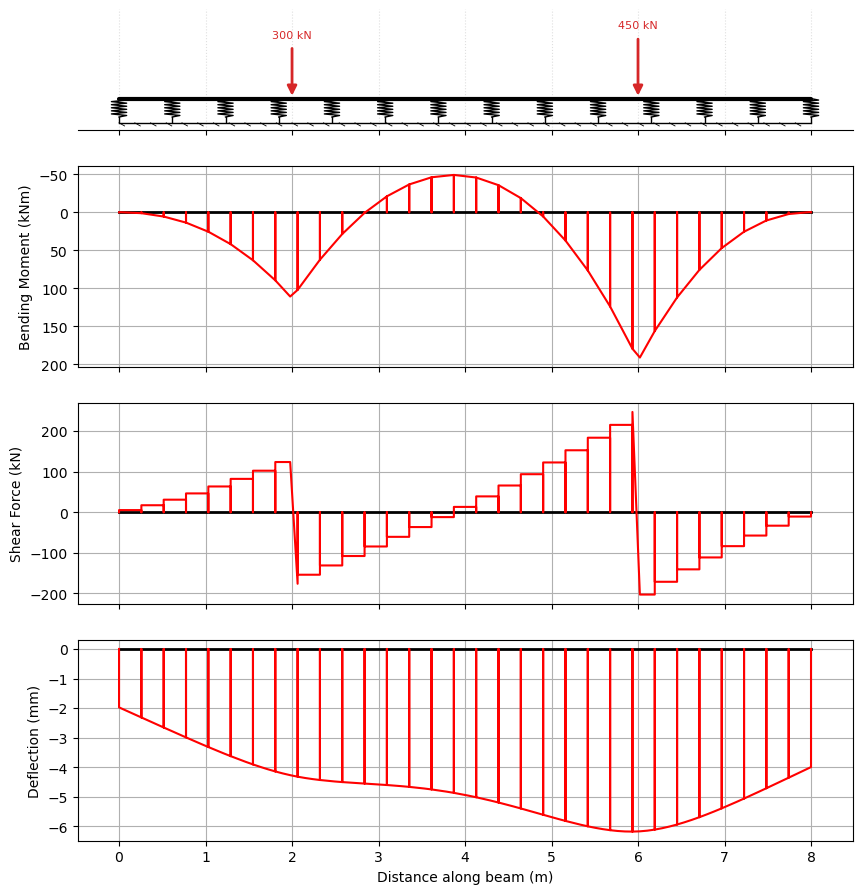

In [3]:
L = 8.0                  # m, footing length
EI = 1.0e5               # kNm^2 (footing flexural rigidity)
kf = 2.0e4               # kN/m per m (subgrade modulus x footing width)

footing = cba.BeamAnalysis([L], EI, [0, 0, 0, 0], kf=kf)
footing.add_pl(i_span=1, p=300, a=2.0)   # column 1
footing.add_pl(i_span=1, p=450, a=6.0)   # column 2
footing.analyze()
res = footing.beam_results.results

pressure = kf * (-res.D)                  # bearing pressure
print(f"max hogging/sagging moment: {res.M.min():.1f} / {res.M.max():.1f} kNm")
print(f"max bearing pressure: {pressure.max():.1f} kN/m")

footing.plot_results(show_beam=True);

## Notes

- `kf` may be set per member, so a continuous beam can rest on a foundation over part of its length and be conventionally supported elsewhere (the schematic draws the springs only under the foundation members).
- The mesh density defaults to the characteristic length; see `pycba.foundation.auto_subdivisions`.
- Current support: prismatic, fixed-fixed members without shear flexibility (`GAv`), carrying UDL, point and partial-UDL loads. Other combinations raise a clear `NotImplementedError`.